In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#using evaluation metrics from core/evaluation.py
import sys
import os
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
from core.evaluation import evaluate_strategy_full, plot_strategy_vs_buy_hold

In [5]:
## ETH
# Load both CSVs
trend_df = pd.read_csv("../datasets/eth_rolling_trend_strength.csv")
vol_df = pd.read_csv("../datasets/eth_rolling_vol.csv")

# Keep only the columns you need from vol_df
vol_df = vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
vol_df = vol_df.rename(columns={
    "position": "vol_position",
})

trend_df = trend_df[[
    "date",
    "position",]]

trend_df = trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
eth_combined = trend_df.merge(vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
eth_combined["position"] = 0

eth_combined.loc[
    (eth_combined["trend_position"] == 1) & (eth_combined["vol_position"] == 1),
    "position"
] = 1

eth_combined.loc[
    (eth_combined["trend_position"] == -1) & (eth_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
#eth_combined.to_csv("../datasets/eth_rolling_combined_strategy.csv", index=False)

eth_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,NaN,NaN,0
1,2018-01-02,0,NaN,NaN,0
2,2018-01-03,0,NaN,NaN,0
3,2018-01-04,0,NaN,NaN,0
4,2018-01-05,0,NaN,NaN,0


In [6]:
## BTC
# Load both CSVs
btc_trend_df = pd.read_csv("../datasets/btc_rolling_trend_strength.csv")
btc_vol_df = pd.read_csv("../datasets/btc_rolling_vol.csv")

# Keep only the columns you need from vol_df
btc_vol_df = btc_vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
btc_vol_df = btc_vol_df.rename(columns={
    "position": "vol_position",
})

btc_trend_df = btc_trend_df[[
    "date",
    "position",]]

btc_trend_df = btc_trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
btc_combined = btc_trend_df.merge(btc_vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
btc_combined["position"] = 0

btc_combined.loc[
    (btc_combined["trend_position"] == 1) & (btc_combined["vol_position"] == 1),
    "position"
] = 1

btc_combined.loc[
    (btc_combined["trend_position"] == -1) & (btc_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
#btc_combined.to_csv("../datasets/btc_rolling_combined_strategy.csv", index=False)

btc_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,NaN,NaN,0
1,2018-01-02,0,NaN,NaN,0
2,2018-01-03,0,NaN,NaN,0
3,2018-01-04,0,NaN,NaN,0
4,2018-01-05,0,NaN,NaN,0


### Evaluation


--- Final Strategy Performance ---
cumulative_pnl: 43.1569
average_daily_pnl: 0.0015
max_drawdown: -0.3713
annualised_return: 0.6053
sharpe_ratio_rf_3pct: 1.3034
daily_std_dev: 0.0210
annualised_volatility: 0.4005
exposure_rate: 0.2167
total_turnover: 196.0000
number_of_trades_total: 98.0000
number_of_complete_trades: 98.0000
win_rate: 0.6327
average_trade_return: 0.0477
median_trade_return: 0.0170
average_win_return: 0.1044
average_loss_return: -0.0501
profit_factor: 3.5907
payoff_ratio: 2.0849
expectancy_per_trade: 0.0477
best_trade: 0.8243
worst_trade: -0.1942
average_holding_periods: 6.4592
median_holding_periods: 4.0000
long_trades: 74.0000
short_trades: 24.0000


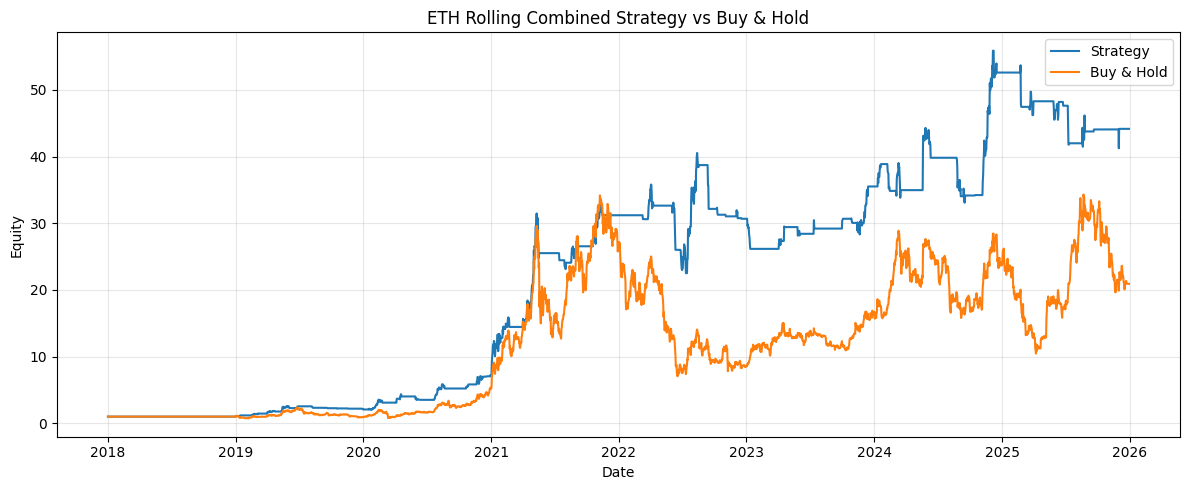

In [7]:
#ETH
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(eth_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="ETH Rolling Combined Strategy vs Buy & Hold")
plt.show()


--- Final Strategy Performance ---
cumulative_pnl: 2.9901
average_daily_pnl: 0.0006
max_drawdown: -0.5036
annualised_return: 0.1888
sharpe_ratio_rf_3pct: 0.6451
daily_std_dev: 0.0149
annualised_volatility: 0.2848
exposure_rate: 0.1883
total_turnover: 210.0000
number_of_trades_total: 105.0000
number_of_complete_trades: 105.0000
win_rate: 0.5524
average_trade_return: 0.0175
median_trade_return: 0.0037
average_win_return: 0.0633
average_loss_return: -0.0390
profit_factor: 2.0028
payoff_ratio: 1.6229
expectancy_per_trade: 0.0175
best_trade: 0.5864
worst_trade: -0.2071
average_holding_periods: 5.2381
median_holding_periods: 3.0000
long_trades: 83.0000
short_trades: 22.0000


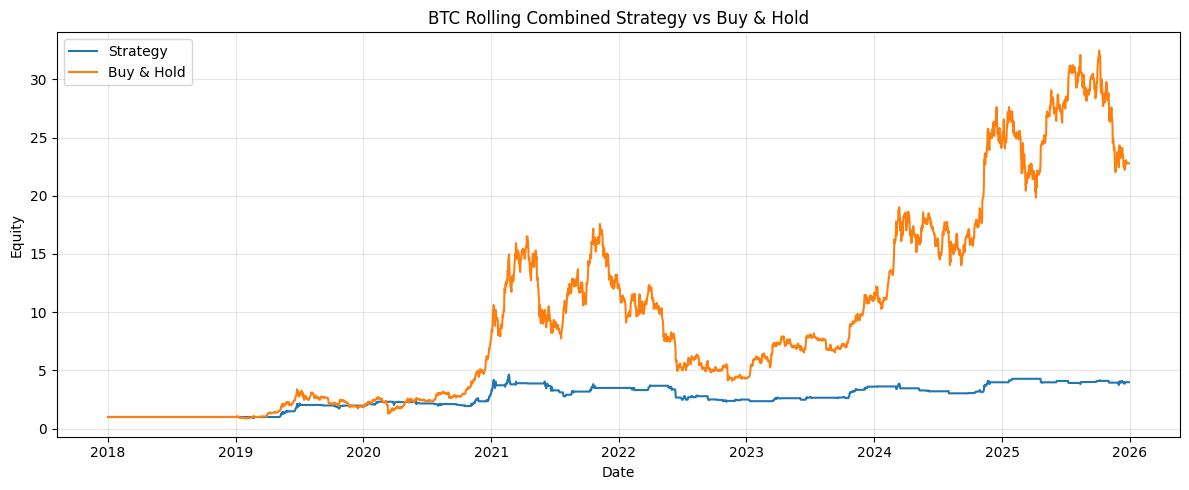

In [8]:
#BTC
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(btc_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="BTC Rolling Combined Strategy vs Buy & Hold")
plt.show()

## Rolling Combined Diagnostics

The diagnostics break performance into exposure, run length, return concentration, underexposure, and signal-confirmation lag. This helps show whether performance comes from being invested more often, capturing longer profitable runs, or avoiding/ missing regime changes.


In [ ]:

ROOT = Path.cwd().parent if Path.cwd().name == "Adaptive" else Path.cwd()
OUTPUT_DIR = ROOT / "outputs" / "strategy_reports" / "04_rolling_window"


def build_rolling_combined_for_diagnostics(asset):
    prefix = asset.lower()
    trend = pd.read_csv(ROOT / "datasets" / f"{prefix}_rolling_trend_strength.csv", parse_dates=["date"])
    vol = pd.read_csv(ROOT / "datasets" / f"{prefix}_rolling_vol.csv", parse_dates=["date"])

    trend = trend[["date", "position"]].rename(columns={"position": "trend_position"})
    vol = vol[["date", "price", "log_return", "position", "regime"]].rename(
        columns={"position": "vol_position", "regime": "vol_regime"}
    )

    df = trend.merge(vol, on="date", how="left").sort_values("date").reset_index(drop=True)
    df["price"] = df["price"].ffill()
    df["asset_ret"] = df["price"].pct_change().fillna(0.0)
    df["trend_position"] = df["trend_position"].fillna(0).astype(int)
    df["vol_position"] = df["vol_position"].fillna(0).astype(int)
    df["position"] = np.where(df["trend_position"].eq(df["vol_position"]), df["trend_position"], 0).astype(int)
    df["trade"] = df["position"].diff().fillna(df["position"]).astype(int)
    df["filter_agrees"] = df["trend_position"].eq(df["vol_position"]) & df["trend_position"].ne(0)
    df["strategy_ret"] = df["position"] * df["asset_ret"]
    df["strategy_log_ret"] = np.log1p(df["strategy_ret"])
    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()
    return df


def extract_invested_runs(df, asset):
    rows = []
    run_group = df["position"].ne(df["position"].shift()).cumsum()

    for _, group in df.groupby(run_group):
        if group["position"].iloc[0] == 0:
            continue
        rows.append({
            "asset": asset,
            "run_id": len(rows) + 1,
            "start": group["date"].iloc[0].date().isoformat(),
            "end": group["date"].iloc[-1].date().isoformat(),
            "duration_days": int(len(group)),
            "side": int(group["position"].iloc[0]),
            "run_return": float(np.prod(1 + group["strategy_ret"]) - 1),
            "run_log_return": float(group["strategy_log_ret"].sum()),
            "max_abs_daily_return": float(group["strategy_ret"].abs().max()),
        })
    return pd.DataFrame(rows)


def invested_day_quality(df):
    invested = df[df["position"].ne(0)]
    flat = df[df["position"].eq(0)]
    if invested.empty:
        return {
            "invested_day_avg_return": pd.NA,
            "invested_day_median_return": pd.NA,
            "invested_day_win_rate": pd.NA,
            "flat_day_avg_asset_abs_return": float(flat["asset_ret"].abs().mean()) if not flat.empty else pd.NA,
        }
    return {
        "invested_day_avg_return": float(invested["strategy_ret"].mean()),
        "invested_day_median_return": float(invested["strategy_ret"].median()),
        "invested_day_win_rate": float(invested["strategy_ret"].gt(0).mean()),
        "flat_day_avg_asset_abs_return": float(flat["asset_ret"].abs().mean()) if not flat.empty else pd.NA,
    }


def run_concentration(runs):
    if runs.empty:
        return {
            "run_count": 0,
            "avg_run_duration_days": pd.NA,
            "median_run_duration_days": pd.NA,
            "max_run_duration_days": pd.NA,
            "positive_run_count": 0,
            "positive_run_log_return_sum": pd.NA,
            "top_1_positive_run_share": pd.NA,
            "top_3_positive_run_share": pd.NA,
            "top_5_positive_run_share": pd.NA,
            "top_1_run_log_return": pd.NA,
            "top_3_run_log_return_sum": pd.NA,
        }

    positive = runs[runs["run_log_return"] > 0].sort_values("run_log_return", ascending=False)
    positive_sum = float(positive["run_log_return"].sum())

    def top_share(n):
        if positive_sum <= 0:
            return pd.NA
        return float(positive.head(n)["run_log_return"].sum() / positive_sum)

    return {
        "run_count": int(len(runs)),
        "avg_run_duration_days": float(runs["duration_days"].mean()),
        "median_run_duration_days": float(runs["duration_days"].median()),
        "max_run_duration_days": int(runs["duration_days"].max()),
        "positive_run_count": int(len(positive)),
        "positive_run_log_return_sum": positive_sum,
        "top_1_positive_run_share": top_share(1),
        "top_3_positive_run_share": top_share(3),
        "top_5_positive_run_share": top_share(5),
        "top_1_run_log_return": float(positive["run_log_return"].iloc[0]) if not positive.empty else pd.NA,
        "top_3_run_log_return_sum": float(positive.head(3)["run_log_return"].sum()) if not positive.empty else pd.NA,
    }


def underexposure(df):
    trend_only = df["trend_position"].ne(0) & df["vol_position"].eq(0)
    vol_only = df["vol_position"].ne(0) & df["trend_position"].eq(0)
    opposite = df["trend_position"].ne(0) & df["vol_position"].ne(0) & df["trend_position"].ne(df["vol_position"])
    blocked = df["position"].eq(0) & (trend_only | vol_only | opposite)
    trend_only_ret = df.loc[trend_only, "trend_position"] * df.loc[trend_only, "asset_ret"]
    vol_only_ret = df.loc[vol_only, "vol_position"] * df.loc[vol_only, "asset_ret"]
    return {
        "filter_agreement_rate": float(df["filter_agrees"].mean()),
        "blocked_exposure_days": int(blocked.sum()),
        "blocked_exposure_rate": float(blocked.mean()),
        "trend_signal_blocked_by_vol_days": int(trend_only.sum()),
        "vol_signal_blocked_by_trend_days": int(vol_only.sum()),
        "opposite_signal_days": int(opposite.sum()),
        "missed_return_if_trend_signal_followed": float(np.prod(1 + trend_only_ret) - 1) if len(trend_only_ret) else 0.0,
        "missed_return_if_vol_signal_followed": float(np.prod(1 + vol_only_ret) - 1) if len(vol_only_ret) else 0.0,
    }


def lag_events(df, source_col, max_wait_days=30):
    rows = []
    source = df[source_col].to_numpy()
    combined = df["position"].to_numpy()
    for idx in range(1, len(df)):
        if source[idx] == 0 or source[idx - 1] == source[idx]:
            continue
        target = source[idx]
        wait = pd.NA
        matched_idx = None
        for j in range(idx, min(idx + max_wait_days + 1, len(df))):
            if combined[j] == target:
                wait = j - idx
                matched_idx = j
                break
            if source[j] != target:
                break
        end_idx = matched_idx if matched_idx is not None else min(idx + max_wait_days, len(df) - 1)
        missed_slice = df.iloc[idx:end_idx + 1]
        rows.append({
            "date": df["date"].iloc[idx].date().isoformat(),
            "source": source_col,
            "target_position": int(target),
            "days_until_combined_confirms": wait,
            "missed_directional_return_until_confirm": float(np.prod(1 + target * missed_slice["asset_ret"]) - 1),
        })
    return pd.DataFrame(rows)


def lag_summary(df):
    events = pd.concat([lag_events(df, "trend_position"), lag_events(df, "vol_position")], ignore_index=True)
    confirmed = events.dropna(subset=["days_until_combined_confirms"])
    return {
        "signal_change_events": int(len(events)),
        "confirmed_signal_change_events": int(len(confirmed)),
        "avg_days_until_combined_confirms": float(confirmed["days_until_combined_confirms"].mean()) if not confirmed.empty else pd.NA,
        "median_days_until_combined_confirms": float(confirmed["days_until_combined_confirms"].median()) if not confirmed.empty else pd.NA,
        "unconfirmed_within_30d_events": int(events["days_until_combined_confirms"].isna().sum()),
        "missed_return_until_confirm_sum": float(events["missed_directional_return_until_confirm"].sum()) if not events.empty else 0.0,
    }, events


def post_vol_regime_change(df, window=5):
    change_idxs = df.index[df["vol_regime"].notna() & df["vol_regime"].ne(df["vol_regime"].shift())].tolist()[1:]
    rows = []
    for idx in change_idxs:
        post = df.iloc[idx:min(idx + window, len(df))]
        rows.append({"underexposed_days": int((post["position"] == 0).sum()), "window_days": int(len(post))})
    post_df = pd.DataFrame(rows)
    return {
        "vol_regime_change_count": int(len(change_idxs)),
        "avg_underexposed_days_after_vol_regime_change_5d": float(post_df["underexposed_days"].mean()) if not post_df.empty else pd.NA,
        "underexposed_share_after_vol_regime_change_5d": float(post_df["underexposed_days"].sum() / post_df["window_days"].sum()) if not post_df.empty else pd.NA,
    }


summary_rows = []
run_frames = []
lag_frames = []
for asset in ["BTC", "ETH"]:
    diagnostics_df = build_rolling_combined_for_diagnostics(asset)
    runs = extract_invested_runs(diagnostics_df, asset)
    lag_stats, events = lag_summary(diagnostics_df)
    summary_rows.append({
        "asset": asset,
        "n_days": int(len(diagnostics_df)),
        "exposure_rate": float((diagnostics_df["position"] != 0).mean()),
        "total_return": float(diagnostics_df["equity_curve"].iloc[-1] - 1),
        "total_log_return": float(diagnostics_df["strategy_log_ret"].sum()),
        **invested_day_quality(diagnostics_df),
        **run_concentration(runs),
        **underexposure(diagnostics_df),
        **lag_stats,
        **post_vol_regime_change(diagnostics_df),
    })
    run_frames.append(runs)
    events.insert(0, "asset", asset)
    lag_frames.append(events)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(summary_rows).to_csv(OUTPUT_DIR / "rolling_combined_diagnostics.csv", index=False)
pd.concat(run_frames, ignore_index=True).to_csv(OUTPUT_DIR / "rolling_combined_runs.csv", index=False)
pd.concat(lag_frames, ignore_index=True).to_csv(OUTPUT_DIR / "rolling_combined_lag_events.csv", index=False)

print(f"Generated {OUTPUT_DIR.relative_to(ROOT)} / rolling_combined_diagnostics.csv")
print(f"Generated {OUTPUT_DIR.relative_to(ROOT)} / rolling_combined_runs.csv")
print(f"Generated {OUTPUT_DIR.relative_to(ROOT)} / rolling_combined_lag_events.csv")


Generated outputs\strategy_reports\04_rolling_window / rolling_combined_diagnostics.csv
Generated outputs\strategy_reports\04_rolling_window / rolling_combined_runs.csv
Generated outputs\strategy_reports\04_rolling_window / rolling_combined_lag_events.csv


## Regime Switch Diagnostics

This section measures regime switches during the rolling combined backtest. It reports total switches, average regime duration, and where switches occur across volatility and trend/range market conditions.

In [ ]:
ROOT = Path.cwd().parent if Path.cwd().name == "Adaptive" else Path.cwd()


def load_regime_inputs(asset):
    prefix = asset.lower()
    trend = pd.read_csv(ROOT / "datasets" / f"{prefix}_rolling_trend_strength.csv", parse_dates=["date"])
    vol = pd.read_csv(ROOT / "datasets" / f"{prefix}_rolling_vol.csv", parse_dates=["date"])

    trend = trend[["date", "trend_strength", "position"]].rename(columns={"position": "trend_position"})
    vol = vol[["date", "price", "log_return", "vol_ratio", "regime", "position"]].rename(
        columns={"regime": "trend_range_regime", "position": "vol_position"}
    )

    df = trend.merge(vol, on="date", how="left").sort_values("date").reset_index(drop=True)
    df["trend_position"] = df["trend_position"].fillna(0).astype(int)
    df["vol_position"] = df["vol_position"].fillna(0).astype(int)
    df["combined_position"] = np.where(df["trend_position"].eq(df["vol_position"]), df["trend_position"], 0).astype(int)
    df["asset_ret"] = df["price"].pct_change().fillna(0.0)

    vol_cutoff = df["vol_ratio"].median(skipna=True)
    df["volatility_regime"] = np.where(df["vol_ratio"] >= vol_cutoff, "High Volatility", "Low Volatility")
    df.loc[df["vol_ratio"].isna(), "volatility_regime"] = pd.NA
    df["trend_range_regime"] = df["trend_range_regime"].replace({"Trend": "Trending", "Range": "Ranging"})
    df["combined_market_condition"] = df["volatility_regime"].astype("string") + " / " + df["trend_range_regime"].astype("string")
    return df


def regime_runs(df, regime_col):
    valid = df.dropna(subset=[regime_col]).copy()
    if valid.empty:
        return pd.DataFrame(columns=["regime", "start", "end", "duration_days"])

    group_id = valid[regime_col].ne(valid[regime_col].shift()).cumsum()
    rows = []
    for _, group in valid.groupby(group_id):
        rows.append({
            "regime": group[regime_col].iloc[0],
            "start": group["date"].iloc[0],
            "end": group["date"].iloc[-1],
            "duration_days": int(len(group)),
        })
    return pd.DataFrame(rows)


def switch_events(df, regime_col):
    valid = df.dropna(subset=[regime_col]).copy()
    switched = valid[regime_col].ne(valid[regime_col].shift())
    events = valid[switched].copy().iloc[1:]
    events["previous_regime"] = valid[regime_col].shift().loc[events.index]
    events["new_regime"] = events[regime_col]
    events["switch_type"] = events["previous_regime"].astype(str) + " -> " + events["new_regime"].astype(str)
    return events


def summarize_regime(asset, df, regime_col, label):
    runs = regime_runs(df, regime_col)
    switches = switch_events(df, regime_col)
    by_regime = (
        runs.groupby("regime")["duration_days"]
        .agg(run_count="count", avg_duration_days="mean", median_duration_days="median", max_duration_days="max")
        .reset_index()
    )
    by_regime.insert(0, "asset", asset)
    by_regime.insert(1, "regime_dimension", label)

    return {
        "asset": asset,
        "regime_dimension": label,
        "total_switches": int(len(switches)),
        "avg_run_duration_days": float(runs["duration_days"].mean()) if not runs.empty else pd.NA,
        "median_run_duration_days": float(runs["duration_days"].median()) if not runs.empty else pd.NA,
        "max_run_duration_days": int(runs["duration_days"].max()) if not runs.empty else pd.NA,
    }, by_regime, switches


summary_rows = []
duration_tables = []
switch_distribution_tables = []
condition_switch_tables = []

for asset in ["BTC", "ETH"]:
    df = load_regime_inputs(asset)

    for regime_col, label in [
        ("volatility_regime", "High/Low Volatility"),
        ("trend_range_regime", "Trending/Ranging"),
        ("combined_market_condition", "Volatility x Trend/Range"),
    ]:
        summary, durations, switches = summarize_regime(asset, df, regime_col, label)
        summary_rows.append(summary)
        duration_tables.append(durations)

        if not switches.empty:
            distribution = (
                switches.groupby(["switch_type", "volatility_regime", "trend_range_regime", "combined_position"])
                .size()
                .rename("switch_count")
                .reset_index()
                .sort_values("switch_count", ascending=False)
            )
            distribution.insert(0, "asset", asset)
            distribution.insert(1, "regime_dimension", label)
            switch_distribution_tables.append(distribution)

    combined_switches = switch_events(df, "combined_market_condition")
    if not combined_switches.empty:
        condition_switch = (
            combined_switches.groupby(["switch_type"])
            .agg(
                switch_count=("date", "count"),
                avg_abs_return_on_switch_day=("asset_ret", lambda x: float(x.abs().mean())),
                combined_invested_rate_on_switch_day=("combined_position", lambda x: float((x != 0).mean())),
            )
            .reset_index()
            .sort_values("switch_count", ascending=False)
        )
        condition_switch.insert(0, "asset", asset)
        condition_switch_tables.append(condition_switch)

regime_switch_summary = pd.DataFrame(summary_rows)
regime_duration_by_type = pd.concat(duration_tables, ignore_index=True)
regime_switch_distribution = pd.concat(switch_distribution_tables, ignore_index=True)
combined_condition_switch_distribution = pd.concat(condition_switch_tables, ignore_index=True)

print("Total number of regime switches during the backtest period")
display(regime_switch_summary)

print("Average duration of each regime type")
display(regime_duration_by_type)

print("Distribution of switches across volatility/trend/range conditions")
display(regime_switch_distribution)

print("Distribution of combined market-condition switches")
display(combined_condition_switch_distribution)


Total number of regime switches during the backtest period


,asset,regime_dimension,total_switches,avg_run_duration_days,median_run_duration_days,max_run_duration_days
0,BTC,High/Low Volatility,97,26.020408,16.0,125
1,BTC,Trending/Ranging,41,60.714286,33.5,360
2,BTC,Volatility x Trend/Range,132,19.022388,9.0,125
3,ETH,High/Low Volatility,109,23.181818,12.0,112
4,ETH,Trending/Ranging,32,77.272727,30.0,420
5,ETH,Volatility x Trend/Range,135,18.605839,11.0,84


Average duration of each regime type


,asset,regime_dimension,regime,run_count,avg_duration_days,median_duration_days,max_duration_days
0,BTC,High/Low Volatility,High Volatility,49,26.020408,22.0,125
1,BTC,High/Low Volatility,Low Volatility,49,26.020408,12.0,118
2,BTC,Trending/Ranging,Ranging,21,38.047619,29.0,115
3,BTC,Trending/Ranging,Trending,21,83.380952,57.0,360
4,BTC,Volatility x Trend/Range,High Volatility / Ranging,18,8.833333,4.5,30
5,BTC,Volatility x Trend/Range,High Volatility / Trending,43,25.930233,22.0,125
6,BTC,Volatility x Trend/Range,Low Volatility / Ranging,27,23.703704,19.0,110
7,BTC,Volatility x Trend/Range,Low Volatility / Trending,46,13.804348,7.5,87
8,ETH,High/Low Volatility,High Volatility,55,23.181818,20.0,84
9,ETH,High/Low Volatility,Low Volatility,55,23.181818,11.0,112


Distribution of switches across volatility/trend/range conditions


,asset,regime_dimension,switch_type,volatility_regime,trend_range_regime,combined_position,switch_count
0,BTC,High/Low Volatility,High Volatility -> Low Volatility,Low Volatility,Trending,0,31
1,BTC,High/Low Volatility,Low Volatility -> High Volatility,High Volatility,Trending,0,23
2,BTC,High/Low Volatility,Low Volatility -> High Volatility,High Volatility,Ranging,0,16
3,BTC,High/Low Volatility,High Volatility -> Low Volatility,Low Volatility,Ranging,0,11
4,BTC,High/Low Volatility,Low Volatility -> High Volatility,High Volatility,Trending,1,9
...,...,...,...,...,...,...,...
58,ETH,Volatility x Trend/Range,High Volatility / Ranging -> High Volatility /...,High Volatility,Trending,1,1
59,ETH,Volatility x Trend/Range,High Volatility / Trending -> Low Volatility /...,Low Volatility,Ranging,-1,1
60,ETH,Volatility x Trend/Range,Low Volatility / Ranging -> High Volatility / ...,High Volatility,Ranging,-1,1
61,ETH,Volatility x Trend/Range,High Volatility / Trending -> High Volatility ...,High Volatility,Ranging,-1,1


Distribution of combined market-condition switches


,asset,switch_type,switch_count,avg_abs_return_on_switch_day,combined_invested_rate_on_switch_day
0,BTC,High Volatility / Trending -> Low Volatility /...,36,0.016560,0.166667
1,BTC,Low Volatility / Trending -> High Volatility /...,31,0.053114,0.258065
2,BTC,Low Volatility / Ranging -> High Volatility / ...,16,0.055182,0.000000
3,BTC,Low Volatility / Trending -> Low Volatility / ...,15,0.011625,0.000000
4,BTC,High Volatility / Ranging -> High Volatility /...,10,0.036902,0.200000
5,BTC,Low Volatility / Ranging -> Low Volatility / T...,9,0.014360,0.444444
6,BTC,High Volatility / Ranging -> Low Volatility / ...,8,0.011654,0.000000
7,BTC,High Volatility / Trending -> Low Volatility /...,4,0.006171,0.250000
8,BTC,High Volatility / Trending -> High Volatility ...,2,0.025529,0.000000
9,BTC,Low Volatility / Ranging -> High Volatility / ...,1,0.102319,1.000000
